# KNN variants on the classifier's sentence embeddings

A tenth method: **k-nearest-neighbors, swept across every combination
requested** -- on the same sentence embeddings the classifier head
(`02_train_classifier.ipynb`) and the clustering notebooks are built on
(tokenize -> average token embeddings, frozen `CBOWAttention`), rather
than the classifier head's trained transformer, or notebook 04's sparse
TF-IDF n-gram vectors.

**Grid, per spec**:
- **Balancing**: SMOTE first (from-scratch implementation, adapted from
  notebook 04's sparse version to plain dense `numpy` arrays -- same
  algorithm: interpolate between a real minority-class point and one of
  its *k* nearest same-class neighbors).
- **k**: 1, 10
- **Metric**: cosine, euclidean, **out-of-place**, dot product
- **Weighting**: weighted, unweighted

2 x 4 x 2 = 16 configurations, x 2 script groups = **32 runs**, all
evaluated on the same held-out `test.jsonl` split as every other method.

**Adapting out-of-place (OOP) to embeddings**: OOP is originally a
*rank-frequency-profile* distance (Cavnar & Trenkle 1994, see
`05_cavnar_trenkle_ngram.ipynb`) -- built for comparing which n-grams
rank highest in two documents, not dense vectors. There's no literal
n-gram rank here, so this notebook generalizes it the natural way: each
128-dim embedding vector is turned into a **rank vector** (its own 128
dimensions ranked by value, largest = rank 0), and OOP distance between
two embeddings is `sum(|rank_a[d] - rank_b[d]|)` over all 128 dimensions
-- same "compare by relative ordering, not raw magnitude" idea the
original metric embodies, applied to embedding dimensions instead of
vocabulary terms. Flagged clearly as a generalization, not the textbook
use case.

**Weighting scheme, defined once for all four metrics**: every metric's
raw score is first converted to a "higher = more similar" value
(cosine similarity as-is, dot product as-is, negative Euclidean distance,
negative OOP distance). For **weighted** voting, each of a row's *k*
neighbor scores is shifted so the *k*-th (least similar) neighbor gets
~0 weight and the closest gets the most (`score - min(scores) + eps`) --
this keeps voting well-defined and comparable across four very
different raw score scales (a cosine similarity is bounded to [-1, 1];
a raw dot product or an OOP rank-distance is not) without any
metric-specific special-casing.

Run this notebook's kernel from the GPU venv (`ai-gpu`) -- needed for
the embedder, not for the KNN sweep itself (pure numpy/CPU).


In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors

ROOT = Path.cwd().resolve().parents[1]  # project root, when running from Dialect_Identification/notebooks/
DATA_DIR = ROOT / "Dialect_Identification" / "data"
WORD2VEC_ATTENTION_DIR = ROOT / "Embeddings" / "word2vec_attention"

sys.path.insert(0, str(WORD2VEC_ATTENTION_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Tokenization"))
from model import CBOWAttention  # noqa: E402
from tokenizer_utils import load_tokenizer  # noqa: E402

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")  # embedding lookups only -- GPU not needed


## 1. Script-gating + sentence embeddings (identical to the clustering notebooks)

In [2]:
import re

_MENTION_WITH_FRAGMENT_RE = re.compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_RE = re.compile(r"\[URL\]")
_INLINE_WHITESPACE_RE = re.compile(r"[ \t]+")
_ARABIC_RE = re.compile(r"[\u0600-\u06ff\u0750-\u077f\u08a0-\u08ff\ufb50-\ufdff\ufe70-\ufeff]")
_LATIN_RE = re.compile(r"[a-zA-Z\u00c0-\u024f]")

ARABIC_CLASSES = ["msa", "darija"]
LATIN_CLASSES = ["arabize", "french", "english"]
GROUP_CLASSES = {"arabic": ARABIC_CLASSES, "latin": LATIN_CLASSES}
MAX_CHARS = 500


def clean_for_classification(text: str) -> str:
    text = _MENTION_WITH_FRAGMENT_RE.sub("", text)
    text = _URL_RE.sub("", text)
    return _INLINE_WHITESPACE_RE.sub(" ", text).strip()


def script_of(text: str) -> str:
    has_ar = bool(_ARABIC_RE.search(text))
    has_lat = bool(_LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


def load_group_rows(split: str, group: str) -> list[dict]:
    rows = []
    with (DATA_DIR / f"{split}.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            r = json.loads(line)
            cleaned = clean_for_classification(r["text"])
            if script_of(cleaned) != group:
                continue
            rows.append({"id": r["id"], "text": r["text"], "label": r["label"]})
    return rows


meta = json.loads((WORD2VEC_ATTENTION_DIR / "data" / "meta.json").read_text(encoding="utf-8"))
tok = load_tokenizer(meta["tokenizer"]["key"], meta["tokenizer"]["vocab_size"])
vocab_size = meta["tokenizer"]["vocab_size_actual"]
PAD_ID = 0

checkpoints = sorted(
    (WORD2VEC_ATTENTION_DIR / "models").glob("checkpoint_step*.pt"),
    key=lambda p: int(p.stem.split("step")[-1]),
)
CHECKPOINT = checkpoints[-1]
ckpt = torch.load(CHECKPOINT, map_location=device)
ckpt_args = ckpt["args"]

embedder = CBOWAttention(
    vocab_size=vocab_size, embed_dim=ckpt_args["embed_dim"],
    num_heads=ckpt_args["num_heads"], ff_dim=ckpt_args["ff_dim"],
).to(device)
embedder.load_state_dict(ckpt["model_state_dict"])
embedder.eval()

EMBED_DIM = ckpt_args["embed_dim"]
embedding_matrix = embedder.input_embeddings.weight.detach().cpu().numpy()
print(f"Loaded checkpoint step={ckpt['step']:,} ({CHECKPOINT.name}), embed_dim={EMBED_DIM}")


def sentence_embedding(text: str) -> np.ndarray:
    ids = [i for i in tok.encode(text[:MAX_CHARS]) if i != PAD_ID and i < vocab_size]
    if not ids:
        return np.zeros(EMBED_DIM, dtype=np.float32)
    return embedding_matrix[ids].mean(axis=0).astype(np.float32)


Loaded checkpoint step=675,000 (checkpoint_step675000.pt), embed_dim=128


## 2. SMOTE (from scratch, dense variant)

Same algorithm as notebook 04's sparse version -- interpolate between a
real minority-class point and one of its *k* nearest same-class
neighbors -- adapted to plain dense arrays (no `scipy.sparse` needed
here, embeddings are already dense).

In [3]:
def smote_balance(X: np.ndarray, y: np.ndarray, k: int = 5, random_state: int = SEED):
    rng = np.random.RandomState(random_state)
    classes, counts = np.unique(y, return_counts=True)
    target = counts.max()

    X_parts, y_parts = [X], [y]
    for c, cnt in zip(classes, counts):
        n_needed = target - cnt
        if n_needed <= 0:
            continue
        X_c = X[y == c]
        if X_c.shape[0] < 2:
            idx = rng.randint(0, X_c.shape[0], size=n_needed)
            X_parts.append(X_c[idx])
            y_parts.append(np.full(n_needed, c))
            continue

        n_neighbors = min(k + 1, X_c.shape[0])
        nn_model = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean").fit(X_c)
        base_idx = rng.randint(0, X_c.shape[0], size=n_needed)
        _, neighbor_idx = nn_model.kneighbors(X_c[base_idx])

        synth_rows = []
        for i, b in enumerate(base_idx):
            candidates = neighbor_idx[i][1:]
            nb = candidates[rng.randint(0, len(candidates))] if len(candidates) else b
            gap = rng.uniform(0.0, 1.0)
            synth_rows.append(X_c[b] + gap * (X_c[nb] - X_c[b]))
        X_parts.append(np.stack(synth_rows).astype(np.float32))
        y_parts.append(np.full(n_needed, c))

    return np.concatenate(X_parts).astype(np.float32), np.concatenate(y_parts)


## 3. Load + embed + SMOTE-balance each group

In [4]:
group_data = {}
for group in ("arabic", "latin"):
    classes = GROUP_CLASSES[group]
    label_to_id = {c: i for i, c in enumerate(classes)}

    train_rows = load_group_rows("train", group)
    test_rows = load_group_rows("test", group)
    X_train = np.stack([sentence_embedding(r["text"]) for r in train_rows])
    y_train = np.array([label_to_id[r["label"]] for r in train_rows])
    X_test = np.stack([sentence_embedding(r["text"]) for r in test_rows])
    y_test = np.array([label_to_id[r["label"]] for r in test_rows])

    X_train_bal, y_train_bal = smote_balance(X_train, y_train)

    group_data[group] = dict(
        classes=classes, X_train=X_train_bal, y_train=y_train_bal,
        X_test=X_test, y_test=y_test,
    )
    print(f"{group}: train={len(train_rows):,} -> balanced={X_train_bal.shape[0]:,}  test={len(test_rows):,}")


arabic: train=6,660 -> balanced=8,986  test=1,665


latin: train=4,563 -> balanced=7,446  test=1,142


## 4. Pairwise scoring for all four metrics

Every metric returns a `(n_test, n_train)` array where **higher = more
similar** (Euclidean and OOP distances are negated), so the same top-k
selection and voting code works for all four unchanged. Batched over
test rows to keep memory bounded -- a full `(n_test, n_train, 128)`
broadcast would be tens of GB for the balanced training sets here.

In [5]:
def pairwise_scores(X_test: np.ndarray, X_train: np.ndarray, metric: str, batch_size: int = 200) -> np.ndarray:
    n_test = X_test.shape[0]
    out = np.empty((n_test, X_train.shape[0]), dtype=np.float32)

    if metric in ("cosine", "dot"):
        a, b = X_test, X_train
        if metric == "cosine":
            a = a / np.clip(np.linalg.norm(a, axis=1, keepdims=True), 1e-9, None)
            b = b / np.clip(np.linalg.norm(b, axis=1, keepdims=True), 1e-9, None)
        return (a @ b.T).astype(np.float32)

    if metric == "euclidean":
        train_sq = (X_train ** 2).sum(axis=1)
        for i in range(0, n_test, batch_size):
            chunk = X_test[i:i + batch_size]
            d2 = (chunk ** 2).sum(axis=1, keepdims=True) + train_sq[None, :] - 2 * chunk @ X_train.T
            out[i:i + batch_size] = -np.sqrt(np.clip(d2, 0, None))
        return out

    if metric == "out_of_place":
        # Rank each vector's own 128 dimensions by value (descending -> rank 0 = largest).
        train_ranks = np.argsort(np.argsort(-X_train, axis=1), axis=1).astype(np.int16)
        test_ranks = np.argsort(np.argsort(-X_test, axis=1), axis=1).astype(np.int16)
        for i in range(0, n_test, batch_size):
            chunk = test_ranks[i:i + batch_size].astype(np.int32)
            diff = np.abs(chunk[:, None, :] - train_ranks[None, :, :].astype(np.int32)).sum(axis=2)
            out[i:i + batch_size] = -diff
        return out

    raise ValueError(f"unknown metric: {metric!r}")


## 5. KNN predict (k, weighted/unweighted) from a scores matrix

In [6]:
def knn_predict(scores: np.ndarray, y_train: np.ndarray, k: int, weighted: bool, num_classes: int) -> np.ndarray:
    """scores: (n_test, n_train), higher = more similar."""
    n_test = scores.shape[0]
    # argpartition for the top-k per row (unordered among themselves, fine for voting)
    kth = min(k - 1, scores.shape[1] - 1)
    top_idx = np.argpartition(-scores, kth=kth, axis=1)[:, :k]
    preds = np.empty(n_test, dtype=np.int64)
    for i in range(n_test):
        idx = top_idx[i]
        neighbor_labels = y_train[idx]
        if weighted:
            neighbor_scores = scores[i, idx]
            w = neighbor_scores - neighbor_scores.min() + 1e-6  # shift so the k-th neighbor gets ~0 weight
        else:
            w = np.ones(len(idx))
        votes = np.zeros(num_classes)
        np.add.at(votes, neighbor_labels, w)
        preds[i] = votes.argmax()
    return preds


## 6. Run the full 2 x 4 x 2 grid, per group

In [7]:
K_VALUES = [1, 10]
METRICS = ["cosine", "euclidean", "out_of_place", "dot"]
WEIGHTINGS = [False, True]

results = []
for group, gd in group_data.items():
    for metric in METRICS:
        t0 = time.time()
        scores = pairwise_scores(gd["X_test"], gd["X_train"], metric)
        for k in K_VALUES:
            for weighted in WEIGHTINGS:
                preds = knn_predict(scores, gd["y_train"], k=k, weighted=weighted, num_classes=len(gd["classes"]))
                acc = (preds == gd["y_test"]).mean()
                results.append({
                    "group": group, "metric": metric, "k": k,
                    "weighted": "weighted" if weighted else "unweighted",
                    "accuracy": float(acc),
                })
        print(f"{group:<7} {metric:<13} scored in {time.time() - t0:.1f}s")

import pandas as pd
results_df = pd.DataFrame(results)
results_df.sort_values(["group", "accuracy"], ascending=[True, False])


arabic  cosine        scored in 1.1s


arabic  euclidean     scored in 1.5s


arabic  out_of_place  scored in 16.1s


arabic  dot           scored in 0.6s


latin   cosine        scored in 0.4s


latin   euclidean     scored in 0.7s


latin   out_of_place  scored in 7.3s


latin   dot           scored in 0.5s


,group,metric,k,weighted,accuracy
3,arabic,cosine,10,weighted,0.769970
11,arabic,out_of_place,10,weighted,0.766366
14,arabic,dot,10,unweighted,0.758559
0,arabic,cosine,1,unweighted,0.756757
1,arabic,cosine,1,weighted,0.756757
8,arabic,out_of_place,1,unweighted,0.753153
9,arabic,out_of_place,1,weighted,0.753153
10,arabic,out_of_place,10,unweighted,0.752553
15,arabic,dot,10,weighted,0.751351
2,arabic,cosine,10,unweighted,0.750751


## 7. Best config per group, and the full grid as a heatmap

In [8]:
for group in group_data:
    sub = results_df[results_df["group"] == group].sort_values("accuracy", ascending=False)
    best = sub.iloc[0]
    print(f"{group}: best = metric={best['metric']}  k={best['k']}  {best['weighted']}  "
          f"accuracy={best['accuracy']:.4f}")
    print(sub.to_string(index=False))
    print()


arabic: best = metric=cosine  k=10  weighted  accuracy=0.7700
 group       metric  k   weighted  accuracy
arabic       cosine 10   weighted  0.769970
arabic out_of_place 10   weighted  0.766366
arabic          dot 10 unweighted  0.758559
arabic       cosine  1 unweighted  0.756757
arabic       cosine  1   weighted  0.756757
arabic out_of_place  1   weighted  0.753153
arabic out_of_place  1 unweighted  0.753153
arabic out_of_place 10 unweighted  0.752553
arabic          dot 10   weighted  0.751351
arabic       cosine 10 unweighted  0.750751
arabic    euclidean 10   weighted  0.747748
arabic    euclidean  1 unweighted  0.739940
arabic    euclidean  1   weighted  0.739940
arabic          dot  1   weighted  0.716517
arabic          dot  1 unweighted  0.716517
arabic    euclidean 10 unweighted  0.710511

latin: best = metric=cosine  k=10  unweighted  accuracy=0.8345
group       metric  k   weighted  accuracy
latin       cosine 10 unweighted  0.834501
latin    euclidean 10 unweighted  0.8292

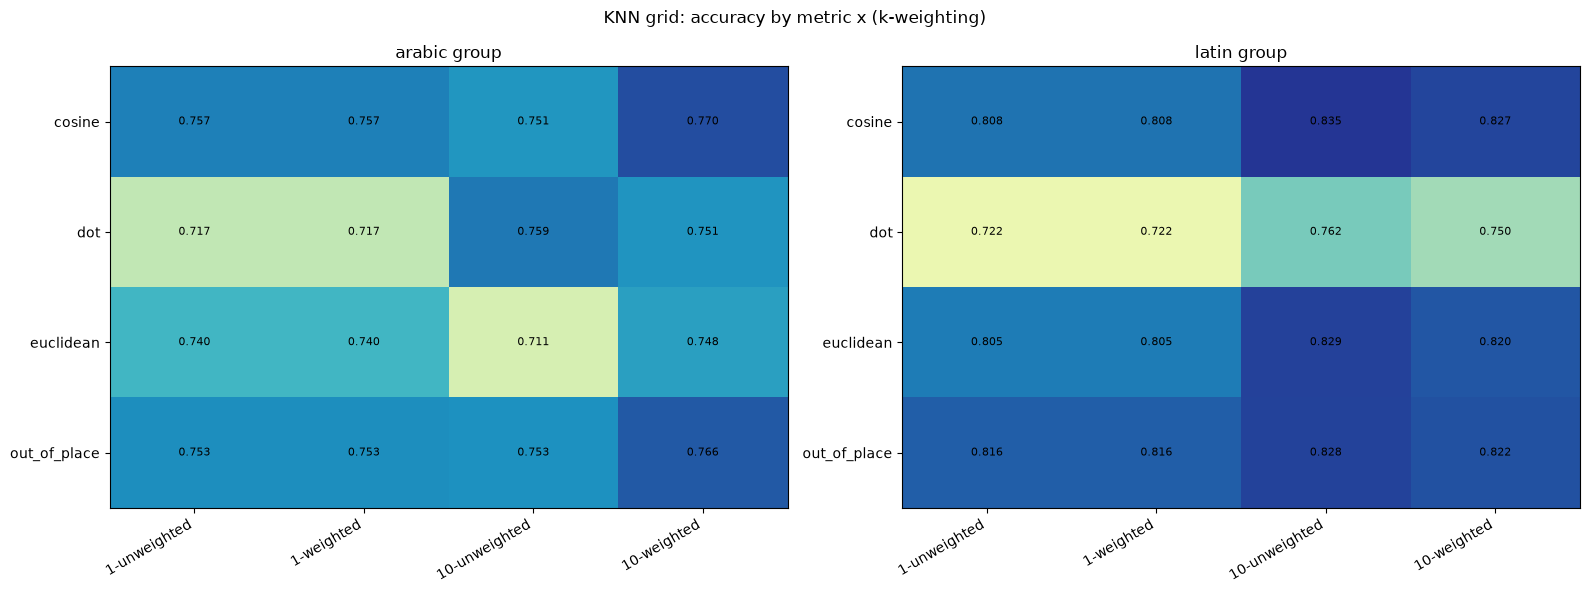

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, group in zip(axes, group_data.keys()):
    sub = results_df[results_df["group"] == group].copy()
    sub["config"] = sub["k"].astype(str) + "-" + sub["weighted"]
    pivot = sub.pivot(index="metric", columns="config", values="accuracy")
    im = ax.imshow(pivot.values, cmap="YlGnBu", vmin=pivot.values.min() - 0.02, vmax=pivot.values.max() + 0.02, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
    ax.set_title(f"{group} group")
fig.suptitle("KNN grid: accuracy by metric x (k-weighting)")
plt.tight_layout()
plt.show()


## 8. Compared against every other method tried on this task

In [10]:
comparison = {
    "regex + real fastText lid.176": (0.340, 0.630),
    "word-cluster baseline (cluster-scored)": (0.562, 0.562),
    "fastText-style (cluster-scored)": (0.582, 0.582),
    "regex/marker-word baseline": (0.699, 0.748),
    "cluster + 200 human-labeled prototypes": (0.701, 0.810),
    "Cavnar & Trenkle (n-gram profiles)": (0.754, 0.844),
    "cluster + majority vote": (0.780, 0.828),
    "classifier head (transformer)": (0.819, 0.863),
    "n-gram + SVM-RBF (best of notebook 04)": (0.833, 0.881),
}
best_arabic = results_df[results_df["group"] == "arabic"]["accuracy"].max()
best_latin = results_df[results_df["group"] == "latin"]["accuracy"].max()
comparison["KNN on sentence embeddings (best of this notebook)"] = (best_arabic, best_latin)

print(f"{'method':<45}{'arabic':>10}{'latin':>10}")
for name, (a, l) in sorted(comparison.items(), key=lambda kv: kv[1][0]):
    print(f"{name:<45}{a:>10.3f}{l:>10.3f}")


method                                           arabic     latin
regex + real fastText lid.176                     0.340     0.630
word-cluster baseline (cluster-scored)            0.562     0.562
fastText-style (cluster-scored)                   0.582     0.582
regex/marker-word baseline                        0.699     0.748
cluster + 200 human-labeled prototypes            0.701     0.810
Cavnar & Trenkle (n-gram profiles)                0.754     0.844
KNN on sentence embeddings (best of this notebook)     0.770     0.835
cluster + majority vote                           0.780     0.828
classifier head (transformer)                     0.819     0.863
n-gram + SVM-RBF (best of notebook 04)            0.833     0.881


## Misclassified examples

A sample of what this method actually gets wrong, per group. For the
single best (metric, k, weighting) config per group -- recomputes its
predictions once more (`pairwise_scores` + `knn_predict`, both already
defined above) since only aggregate accuracy was kept from the original
sweep, not per-row predictions.

In [11]:
import random

random.seed(0)

for group, gd in group_data.items():
    sub = results_df[results_df["group"] == group].sort_values("accuracy", ascending=False)
    best = sub.iloc[0]
    scores = pairwise_scores(gd["X_test"], gd["X_train"], best["metric"])
    preds = knn_predict(scores, gd["y_train"], k=int(best["k"]), weighted=bool(best["weighted"] == "weighted"),
                         num_classes=len(gd["classes"]))

    classes = gd["classes"]
    test_rows = load_group_rows("test", group)  # not cached in group_data -- rebuilt here (cheap)
    wrong = [
        (row["text"], classes[t], classes[p])
        for row, t, p in zip(test_rows, gd["y_test"], preds) if t != p
    ]
    print(f"\n=== {group} (metric={best['metric']}, k={int(best['k'])}, {best['weighted']}): "
          f"{len(wrong)}/{len(test_rows)} misclassified ({len(wrong) / len(test_rows):.1%}) ===")
    for text, true_label, pred_label in random.sample(wrong, min(10, len(wrong))):
        snippet = text[:140] + ("..." if len(text) > 140 else "")
        print(f"\n  true={true_label}  pred={pred_label}")
        print(f"  {snippet!r}")



=== arabic (metric=cosine, k=10, weighted): 383/1665 misclassified (23.0%) ===

  true=darija  pred=msa
  'السعر يتفاوت بتغير الأماكن\nالشقة المعروضة للبيع مكانها روعة وجيرانها والحي هادئ جداا\nوقليل وجود أحياء هادئة في الوقت الحالي\nيسرقوك ونتا فاطن...'

  true=darija  pred=msa
  'سبحان الله 😂😂'

  true=msa  pred=darija
  'ما بلاتوهاتهم يستقبلون مرضى نفسانيين عوض المصحات'

  true=darija  pred=msa
  'الحمد لله مازال كاين الخير*'

  true=darija  pred=msa
  'قوانين أحسن وأفضل ؛ سنعمل المستطاع لكي نحافظ عليها ؛ دمتم بود'

  true=darija  pred=msa
  'هذا طابع لغواطي.'

  true=darija  pred=msa
  'على طريقة ديزاد جوكر \nبرافو وصلت الرسالة و ان شاء الله يبدأ التغيير بأنفسنا'

  true=darija  pred=msa
  'رحمك الله اخي عمر\nإن العين لتدمع و ان القلب ليبكي و ان على فراقك يا غالي لمحزونون'

  true=darija  pred=msa
  'هلا وسهلا ومرحبا بضيفتنا الغالية\nنتمنى لك اقامة ممتعة و جميلة\nفرحت لك من كل اعماق قلبي مع انني لا اعرفك\nبرايك ما هي مفاتيح و اسرار النجاح؟ ف...'

  true=msa  pred=darija
  'شغال شب


=== latin (metric=cosine, k=10, unweighted): 189/1142 misclassified (16.5%) ===

  true=arabize  pred=english
  'GHADNI HADAK RAJEL KI 9ATLOU FARES EL KELB'

  true=french  pred=english
  'vous etes les meilleurs toOoOoOoOoOop'

  true=arabize  pred=english
  'Thankyou vitt fais'

  true=english  pred=arabize
  'dirlna video omegele'

  true=arabize  pred=french
  'Alhamdulillah barokallah'

  true=arabize  pred=french
  '[MENTION] Uii n3rfo vrmnt hyel e mrc bcp bcp ma soeur 😍😘'

  true=arabize  pred=french
  'MOTEUR ACTION ! ca tourne .lis le message ! Mechant noir ! \nDz: absolulent outré on est pas raciste ni au chantage affectif car on a le nif ...'

  true=arabize  pred=english
  '[MENTION] hajajh'

  true=french  pred=arabize
  'Ziada mouaatabara'

  true=arabize  pred=english
  '[MENTION] -و8ظ wald bladi☺'
